In [6]:
import geopandas as gpd
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from keplergl import KeplerGl
import json



In [7]:
assessment_roll_vic = pd.read_csv('2025/2025 victoria.csv')
properties_raw = gpd.read_file('parcels/raw_download.geojson')

Removed 6 rows with invalid geometry:


<Axes: >

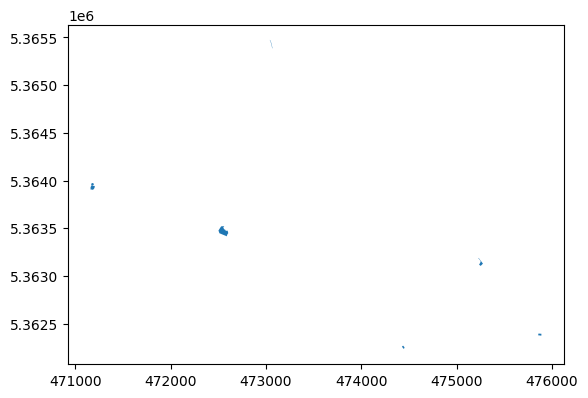

In [8]:
# Remove rows with invalid geometry. Print the rows that get removed
invalid_geometry = properties_raw[~properties_raw.is_valid]
properties = properties_raw[properties_raw.is_valid]
print("Removed {} rows with invalid geometry:".format(len(invalid_geometry)))

invalid_geometry.plot()

In [ ]:
#Assessment roll contains duplicate values for assess_type of GENERAL AND SCHOOL. Drop SCHOOL and only keep GENERAL.
assessment_roll = assessment_roll_vic[assessment_roll_vic['assess_type'] != 'SCHOOL']
#remove the jurisdiction code from properties.Folio 0 - everything that preceeds the first period
properties['Folio'] = properties['Folio'].str.split('.').str[1]
#remove non-numeric characters from properties.Folio
properties['Folio'] = properties['Folio'].str.replace(r'\D', '', regex=True)
#convert to int
properties['Folio'] = properties['Folio'].astype(int)

#left merge properties with assessment_roll on Folio and FOLIO
merged = properties.merge(assessment_roll, left_on='Folio', right_on='FOLIO', how='left')

merged.HOUSE = merged.HOUSE.fillna("")
#delete anything after a period
merged.HOUSE = merged.HOUSE.str.split('.').str[0]

merged['FullAddress'] = merged.HOUSE.astype(str) + " " + merged.STREET
#drop everything except for: FullAddress, Folio, LEGAL_TYPE, assess_abbreviation, land_gross, impr_gross, geometry
merged = merged[['FullAddress', 'Folio', 'LEGAL_TYPE', 'assess_abbreviation', 'land_gross', 'impr_gross', 'geometry']]

#aggregate by common geometry. Sum land_gross and impr_gross, use First for everything else
merged = merged.groupby('geometry').agg({
    'FullAddress': 'first',
    'Folio': 'first',
    'LEGAL_TYPE': 'first',
    'assess_abbreviation': 'first',
    'land_gross': 'sum',
    'impr_gross': 'sum'
}).reset_index()

#move geometry to the end
merged = merged[['FullAddress', 'Folio', 'LEGAL_TYPE', 'assess_abbreviation', 'land_gross', 'impr_gross', 'geometry']]

merged['total_gross'] = merged['land_gross'] + merged['impr_gross']

#convert back to geopandas gdf
merged = gpd.GeoDataFrame(merged, geometry='geometry')

#calculate the area in M2
merged['area'] = merged['geometry'].area
merged['land per m2'] = merged['land_gross'] / merged['area']
merged['total per m2'] = merged['total_gross'] / merged['area']

c:\Users\marki\anaconda3\envs\gis-new\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\marki\anaconda3\envs\gis-new\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,FullAddress,Folio,LEGAL_TYPE,assess_abbreviation,land_gross,impr_gross,geometry,total_gross,area,land per m2,total per m2
0,nan DALLAS RD,2155001,LAND,Business,40531000.0,6000.0,"POLYGON ((472230.076 5361847.604, 472316.283 5...",40537000.0,55636.380498,728.498145,728.605988
1,DALLAS RD,3181007,OTHER,Recreational,88300.0,0.0,"POLYGON ((472986.63 5361667.684, 472985.119 53...",88300.0,1052.496822,83.895740,83.895740
2,nan DOUGLAS ST,2159047,LAND,Residential,13025000.0,383000.0,"POLYGON ((472681.492 5362014.21, 472681.447 53...",13408000.0,2123.550144,6133.596626,6313.954976
3,nan NIAGARA ST,2161009,LAND,Residential,1292000.0,203000.0,"POLYGON ((472673.501 5362096.397, 472647.36 53...",1495000.0,552.960056,2336.515968,2703.631093
4,nan DOUGLAS ST,2161008,LAND,Residential,7209000.0,3031000.0,"POLYGON ((472701.963 5362017.529, 472706.459 5...",10240000.0,2361.614971,3052.572112,4336.015873
...,...,...,...,...,...,...,...,...,...,...,...
14953,nan CRESCENT RD,5335051,LAND,Residential,2947000.0,1827000.0,"POLYGON ((475750.492 5362100.17, 475768.778 53...",4774000.0,940.780966,3132.503853,5074.507430
14954,nan CRESCENT RD,5335052,LAND,Residential,2906000.0,1259000.0,"POLYGON ((475787.034 5362088.866, 475787.571 5...",4165000.0,974.277496,2982.723108,4274.962748
14955,nan CRESCENT RD,5335053,LAND,Residential,2843000.0,560000.0,"POLYGON ((475805.259 5362078.644, 475805.544 5...",3403000.0,1063.609135,2672.974409,3199.483614
14956,nan FOUL BAY RD,5335073,LAND,Residential,2597000.0,1157000.0,"POLYGON ((475805.259 5362078.644, 475823.547 5...",3754000.0,562.011766,4620.899699,6679.575460


In [5]:
def kepler_plot(data, config_name):
    # Load the map configuration from the JSON file
    with open('map_config.json', 'r') as f:
        map_config = json.load(f)
    map = KeplerGl(height=500, config=map_config)
    map.add_data(data=data, name="Merged Data")
    return map

In [6]:
map = KeplerGl(height=500)
map.add_data(data=merged, name="Merged Data")
map

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(data={'Merged Data': {'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,…

In [161]:
import json

# Export the map configuration as a JSON
map_config = map.config
with open('map_config.json', 'w') as f:
    json.dump(map_config, f)

print("Map configuration exported to 'map_config.json'")

print(map_config)

Map configuration exported to 'map_config.json'
{'version': 'v1', 'config': {'visState': {'filters': [], 'layers': [{'id': '2m6bzlf', 'type': 'geojson', 'config': {'dataId': 'Scaled Lots', 'label': 'Scaled Lots', 'color': [179, 173, 158], 'highlightColor': [252, 242, 26, 255], 'columns': {'geojson': 'geometry'}, 'isVisible': True, 'visConfig': {'opacity': 0.8, 'strokeOpacity': 0.8, 'thickness': 0.5, 'strokeColor': [18, 147, 154], 'colorRange': {'name': 'Global Warming', 'type': 'sequential', 'category': 'Uber', 'colors': ['#5A1846', '#900C3F', '#C70039', '#E3611C', '#F1920E', '#FFC300']}, 'strokeColorRange': {'name': 'Global Warming', 'type': 'sequential', 'category': 'Uber', 'colors': ['#5A1846', '#900C3F', '#C70039', '#E3611C', '#F1920E', '#FFC300']}, 'radius': 10, 'sizeRange': [0, 10], 'radiusRange': [0, 50], 'heightRange': [0, 500], 'elevationScale': 5, 'enableElevationZoomFactor': True, 'stroked': True, 'filled': True, 'enable3d': False, 'wireframe': False}, 'hidden': False, 'text

In [162]:
#initial naive estimate of FSR
C = 3000 #3000 $/m2, or approx 900 $/ft2
LS = 0.2 #improvements represent a 20% land share of the total value

merged['FSR'] = (merged['land per m2']/LS - merged['land per m2']) * 1/C

#kepler_plot(merged)

In [163]:
#analyze how lot size affects land value price per m2

#start by importing zoning from harmonized Homes for Living dataset. It's a bit out of date but will work fine for our purposes
zoning = gpd.read_file('zoning/Harmonized_Zones_Dissolved.shp').to_crs(merged.crs)

sfh_areas = zoning[zoning.SIMPLIFIED == 'Single/Duplex']

print(len(merged)) #check number of rows before and after sjoin, which can result in row duplication if there's multiple hits
merged = merged.sjoin(sfh_areas, how='left', predicate='intersects')
print(len(merged))

14958
14958


0        Single/Duplex
1        Single/Duplex
2                Other
3                Other
4                Other
             ...      
14953    Single/Duplex
14954    Single/Duplex
14955    Single/Duplex
14956    Single/Duplex
14957    Single/Duplex
Name: SIMPLIFIED, Length: 14958, dtype: object


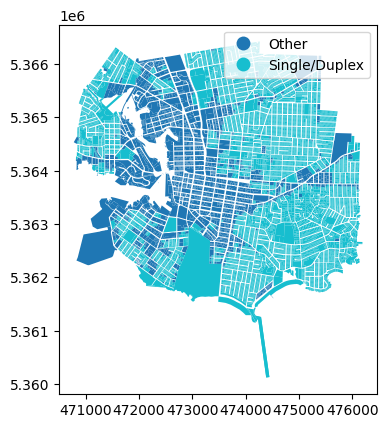

In [11]:
#plot merged using SIMPLIFIED category
#replace NaN values with 'Unknown'
merged['SIMPLIFIED'] = merged['SIMPLIFIED'].fillna('Other')
print(merged.SIMPLIFIED)
merged.plot(column='SIMPLIFIED', legend=True)


sfh_lots = merged[merged['SIMPLIFIED'] == 'Single/Duplex']
other_lots = merged[merged['SIMPLIFIED'] != 'Single/Duplex']


In [164]:
#group lots together based on adjacency; i.e. put each lot in a block in a group
sfh_lots['group'] = None

# Define a function to recursively find adjacent lots
def find_adjacent_lots(lot_index, group_index):
    if sfh_lots.at[lot_index, 'group'] is not None:
        return

    sfh_lots.at[lot_index, 'group'] = group_index

    adjacent_lots_indices = sfh_lots[sfh_lots['geometry'].intersects(sfh_lots.at[lot_index, 'geometry'])].index
    #print("intersecting lots: ", len(adjacent_lots_indices))
    for adj_lot in adjacent_lots_indices:
        find_adjacent_lots(adj_lot, group_index)

for i, row in sfh_lots.iterrows():
    find_adjacent_lots(i, i)

c:\Users\marki\anaconda3\envs\gis-new\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


c:\Users\marki\anaconda3\envs\gis-new\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


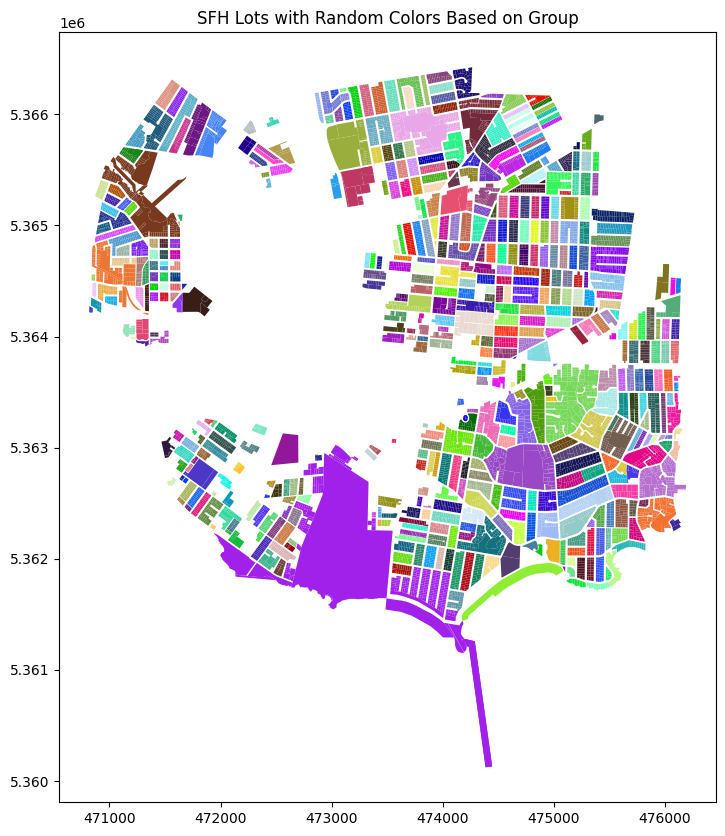

In [165]:
import random

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Generate a random color map for the groups
unique_groups = sfh_lots['group'].unique()
color_map = {group: mcolors.to_hex([random.random() for _ in range(3)]) for group in unique_groups}

# Map the group column to colors
sfh_lots['color'] = sfh_lots['group'].map(color_map)

# Plot the GeoDataFrame with the assigned colors
fig, ax = plt.subplots(figsize=(10, 10))
sfh_lots.plot(ax=ax, color=sfh_lots['color'], legend=True)
plt.title('SFH Lots with Random Colors Based on Group')
plt.show()

<Axes: >

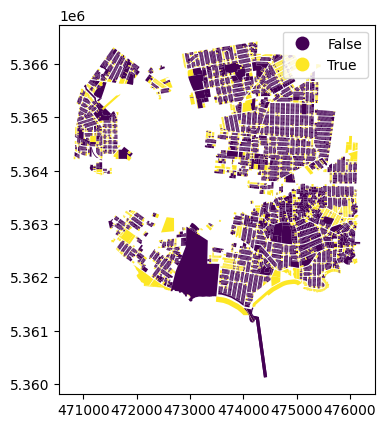

In [166]:
#select corner lots and give them a value of true for sfh_lots.is_corner
#criteria for corner lots is lots that only have two neighbouring lots
sfh_lots['is_corner'] = False
for i, row in sfh_lots.iterrows():
    if len(sfh_lots[sfh_lots['geometry'].intersects(row['geometry'])]) <= 3:
        sfh_lots.at[i, 'is_corner'] = True

sfh_lots.plot(column='is_corner', legend=True, cmap='viridis', vmin=0, vmax=1)

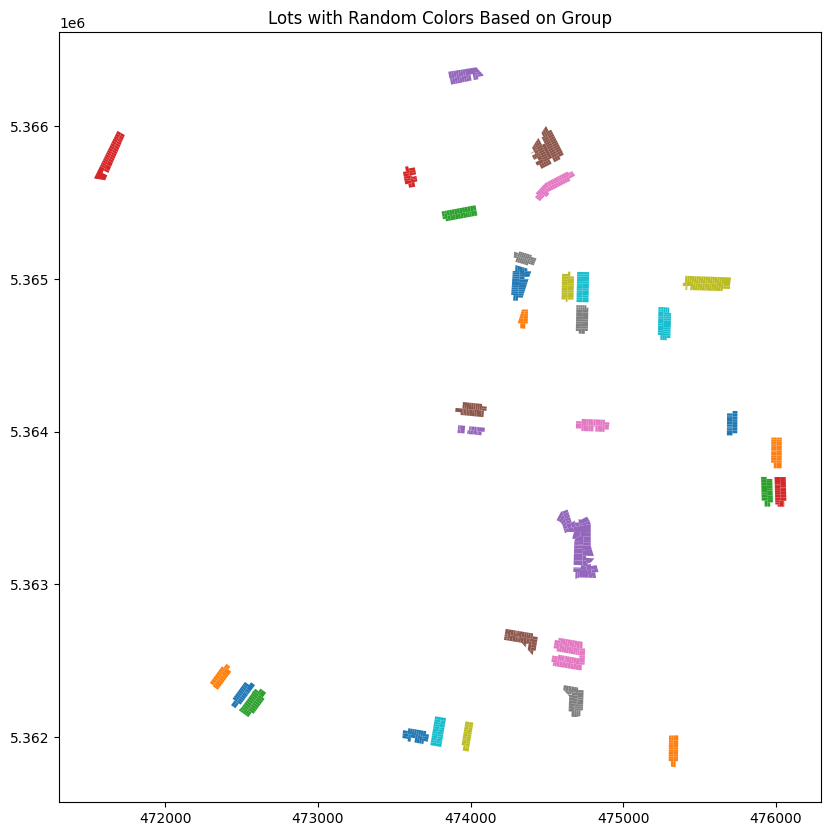

In [167]:
# Drop corner lots
selected_sfh_lots = sfh_lots[~sfh_lots['is_corner']]

#choose number of groups to analyze
n = 32
#select the first n colours of mcolours
colours = list(mcolors.TABLEAU_COLORS.values())[:n]

# Select groups that have at least 8 parcels after throwing out corner lots, and ask there to be a variation in lot size of at least a factor of 1.25
selected_sfh_lots = selected_sfh_lots.groupby('group').filter(lambda x: len(x) >= 8)
selected_sfh_lots = selected_sfh_lots.groupby('group').filter(lambda x: x['area'].max() / x['area'].min() >= 1.25)

#exclude groups where any lot is greater than 5000 m^2 (exclude outliers like beacon hill park)
selected_sfh_lots = selected_sfh_lots.groupby('group').filter(lambda x: x['area'].max() <= 5000)

#pick n random groups
selected_sfh_lots = selected_sfh_lots[selected_sfh_lots['group'].isin(selected_sfh_lots['group'].sample(n=n, random_state=42))]

# Map the group column to colors
selected_sfh_lots['color'] = selected_sfh_lots['group'].map({group: colours[i % len(colours)] for i, group in enumerate(selected_sfh_lots['group'].unique())})

# Plot the GeoDataFrame with the assigned colors
fig, ax = plt.subplots(figsize=(10, 10))
selected_sfh_lots.plot(ax=ax, color=selected_sfh_lots['color'], legend=True)
plt.title('Lots with Random Colors Based on Group')
plt.show()


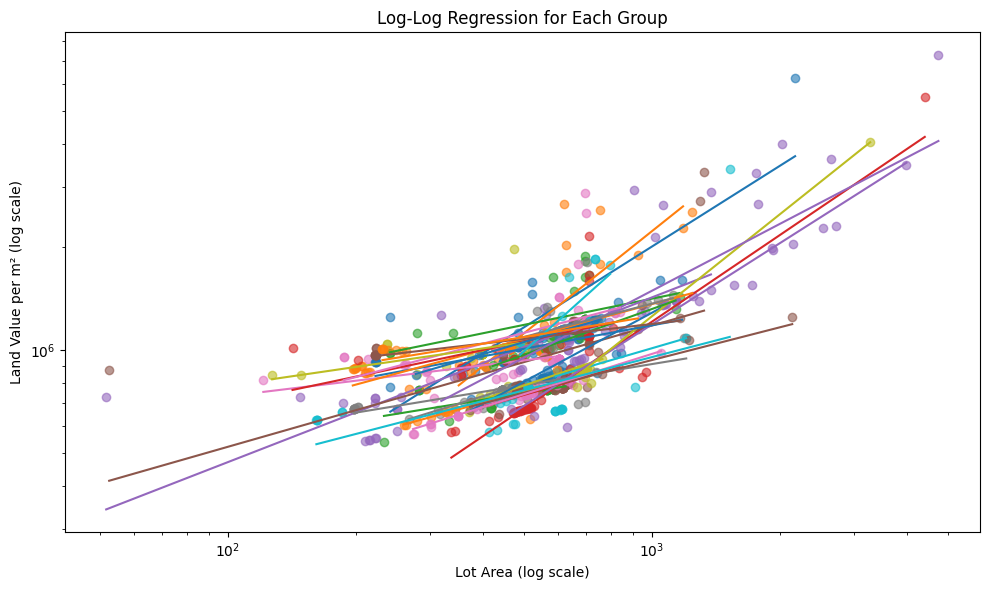

In [168]:
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Loop through each group
for group in selected_sfh_lots['group'].unique():
    try:
        group_data = selected_sfh_lots[selected_sfh_lots['group'] == group]
        X = np.log(group_data['area']).values.reshape(-1, 1)
        y = np.log(group_data['land_gross']).values
        model = LinearRegression()
        model.fit(X, y)
        c = model.intercept_
        b = model.coef_[0]

        #update lots gdf with intercept and beta parameter
        selected_sfh_lots.loc[selected_sfh_lots['group'] == group, 'c'] = c
        selected_sfh_lots.loc[selected_sfh_lots['group'] == group, 'b'] = b

        # Plot the points for the group
        ax.scatter(group_data['area'], group_data['land_gross'], label=f'Group {group}', alpha=0.6, color=group_data['color'].iloc[0])

        # Plot the regression line
        x_vals = np.linspace(group_data['area'].min(), group_data['area'].max(), 100)
        y_vals = np.exp(c) * x_vals**b
        ax.plot(x_vals, y_vals, label=f'Regression Group {group}', color=group_data['color'].iloc[0])
    except Exception as e:
        had_error = True
        print(f"Error in group {group}: {e}")
        # Flag the group with an error
        sfh_lots.loc[sfh_lots['group'] == group, 'error_flag'] = True
        continue

# Set log scale for both axes
ax.set_xscale('log')
ax.set_yscale('log')

# Set labels and title
ax.set_xlabel('Lot Area (log scale)')
ax.set_ylabel('Land Value per m² (log scale)')
ax.set_title('Log-Log Regression for Each Group')
plt.tight_layout()
plt.show()


Median slope:  0.3427177735619717


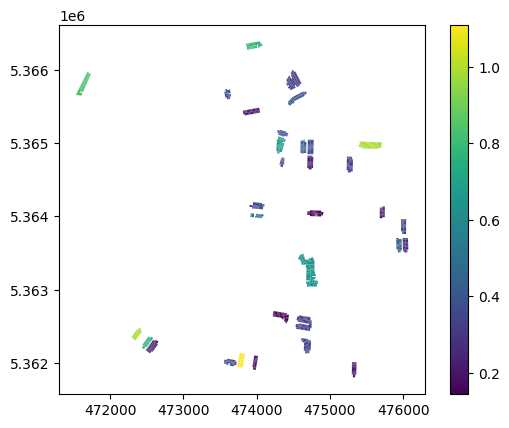

In [169]:
#plot the lots (selected groups only) but now colour by 'm' parameter from regression
selected_sfh_lots.plot(column='b', legend=True, cmap='viridis')
print("Median slope: ", selected_sfh_lots['b'].median())

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: y       
No. Observations: 884     Method:             REML    
No. Groups:       32      Scale:              0.0303  
Min. group size:  14      Log-Likelihood:     102.4498
Max. group size:  55      Converged:          Yes     
Mean group size:  27.6                                
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
x1           0.416    0.016 26.809 0.000  0.385  0.446
Group Var  123.282  178.866                           

11.39981308336767
11.391300480862602
11.377647724569972
10.867712818773425
11.213690005811483
11.147430605771907
11.16176429165093
11.033379019839327
10.99445428995361
10.98212695391093
11.059821669873186
10.97508595044831
10.940865459103216
10.91858492461311
10.975607100020918
10.928534576266523
10.938434342556455
11.013295814292771
10.986280530

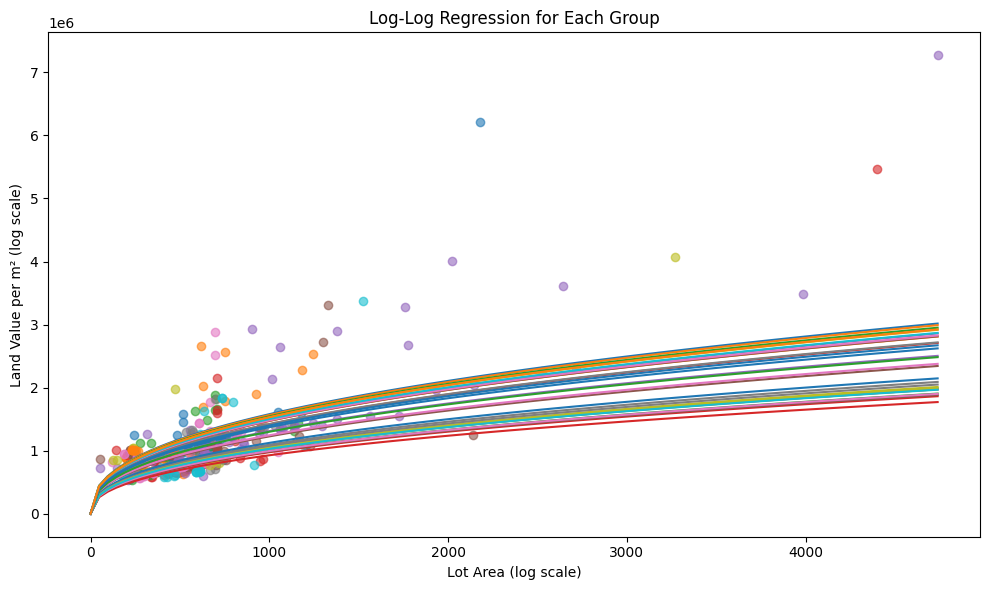

Beta is:  0.4158805772921364


In [170]:
#fit a random intercept model that estimates a fixed slope and allows the intercept to vary by group
import statsmodels.api as sm

# Drop lots with error_flag set to True
selected_lots = selected_sfh_lots[selected_sfh_lots['error_flag'] != True]
# Prepare the data for the model
X = np.log(selected_lots['area']).values
y = np.log(selected_lots['land_gross']).values
groups = selected_lots['group'].values

# Fit the random intercept model
model = sm.MixedLM(y, X, groups=groups)
result = model.fit()

# Print the model summary
print(result.summary())

#plot each group's line using the various intercepts and the fixed slope
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Generate x values ranging from 0 to the maximum of the 'area' column
x_vals = np.linspace(0, selected_lots['area'].max(), 100)

# Get the fixed slope from the model
fixed_slope = result.params[0]

for group in selected_sfh_lots['group'].unique():
    group_intercept = result.random_effects[group]['Group Var']
    print(group_intercept)

    y_vals = np.exp(group_intercept) * x_vals ** fixed_slope
    ax.plot(x_vals, y_vals, label=f'Group {group}')

    #plot points as well
    group_data = selected_sfh_lots[selected_sfh_lots['group'] == group]
    ax.scatter(group_data['area'], group_data['land_gross'], color=group_data['color'].iloc[0], alpha=0.6)

# Set labels and title
ax.set_xlabel('Lot Area (log scale)')
ax.set_ylabel('Land Value per m² (log scale)')
ax.set_title('Log-Log Regression for Each Group')
plt.tight_layout()
plt.show()

beta = fixed_slope

print("Beta is: ", beta)

In [171]:
print("Average lot size for reference (M2): ", selected_sfh_lots['area'].median())
sfh_lots['land per m2 scaled'] = (sfh_lots['land_gross'] * (550 /sfh_lots['area']) ** beta) / 550

#estimate of FSR using adjusted lot sizes
C = 3000 #3000 $/m2, or approx 900 $/ft2
LS = 0.2 #improvements represent a 20% land share of the total value

sfh_lots['FSR'] = (sfh_lots['land per m2 scaled']/LS - sfh_lots['land per m2 scaled']) * 1/C

#concat them to the (non-sfh) other lots

all_lots = pd.concat([sfh_lots, other_lots], ignore_index=True)
all_lots = gpd.GeoDataFrame(all_lots, geometry='geometry')

#replace nan values in land per m2 scaled with values from land per m2 column
all_lots['land per m2 scaled'] = all_lots['land per m2 scaled'].fillna(all_lots['land per m2'])

#drop index_right
all_lots = all_lots.drop(columns=['index_right'], errors='ignore')

Average lot size for reference (M2):  566.7267564503957


In [172]:
#round all values to 0.1 decimal value
all_lots = all_lots.round(1)

map_1 = KeplerGl(height=500)
# Load the map configuration from the JSON file
with open('kepler_configs/final_results_config.json', 'r') as f:
    map_config = json.load(f)

map_1.add_data(data=all_lots, name="Lots")
map_1.config = map_config
map_1

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


c:\Users\marki\anaconda3\envs\gis-new\Lib\site-packages\jupyter_client\session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


KeplerGl(config={'version': 'v1', 'config': {'visState': {'filters': [], 'layers': [{'id': 'qciusd', 'type': '…

In [173]:
#export configuration to json
map_1_config = map_1.config
with open('kepler_configs/final_results_config.json', 'w') as f:
    json.dump(map_1_config, f)

#export to html
map_1.save_to_html(file_name='final_results.html')


Map saved to final_results.html!
